# Baseline DenseNet

## Objective
Establish a lower-bound baseline for DenseNet-121 trained from scratch with a direct
linear head, no class weighting, and no regularisation. All subsequent experiments
build on this reference point.
 
## Architecture
 
| Component | 01. Baseline |
|---|---|
| Pretrained | False |
| Frozen backbone | False |
| Hidden dim | 0 (direct linear head) |
| Dropout | 0.0 |
| Pos weight | None |
| Optimiser | AdamW |
| Weight decay | 1e-4 |
| LR | 1e-3 |
| Epochs | 30 |
 
## Hypothesis
Training from random initialisation with no class-balancing establishes the performance
floor. The majority class (nevus) will dominate and melanoma recall will be poor, but
this gives a clean reference point for all subsequent iterations.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
 
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))
 
from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.densenet import get_densenet121
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
 
import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_densenet121(
    num_classes=1,
    pretrained=False,
    freeze_backbone=False,
    dropout=0.0,
    hidden_dim=0,
).to(device)
 
criterion = nn.BCEWithLogitsLoss()
 
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
 
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print('Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 0 | Pos weight: None')

Trainable params: 6,954,881 / 6,954,881
Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 0 | Pos weight: None


In [4]:
from pathlib import Path

path = Path("C:/Users/1008462/Desktop/50.039-Deep-Learning/data_new/images/train/ISIC_0026252.jpg")
print(path.exists())

True


In [5]:
import os

root = "C:/Users/1008462/Desktop/50.039-Deep-Learning"

for dirpath, _, filenames in os.walk(root):
    if "ISIC_0026252.jpg" in filenames:
        print("Found at:", os.path.join(dirpath, "ISIC_0026252.jpg"))

Found at: C:/Users/1008462/Desktop/50.039-Deep-Learning\data_new\images\train\ISIC_0026252.jpg
Found at: C:/Users/1008462/Desktop/50.039-Deep-Learning\data_new\raw\dataverse_files\HAM10000_images_combined_600x450\ISIC_0026252.jpg


## Training Loop

In [6]:
best_val_auc = 0.0
train_history, val_history = [], []
 
for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)
 
    scheduler.step()
 
    train_history.append(train_metrics)
    val_history.append(val_metrics)
 
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")
 
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/densenet121_baseline_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 0.3338, Bal Acc: 0.5035, Recall: 0.0137, F2: 0.0168, AUC: 0.6728
  Val   | Loss: 0.3502, Bal Acc: 0.5000, Recall: 0.0000, F2: 0.0000, AUC: 0.7375
  -> Saved best model (val AUC: 0.7375)


Epoch [2/30]
  Train | Loss: 0.3159, Bal Acc: 0.4996, Recall: 0.0000, F2: 0.0000, AUC: 0.7211
  Val   | Loss: 0.3452, Bal Acc: 0.5000, Recall: 0.0000, F2: 0.0000, AUC: 0.7010


Epoch [3/30]
  Train | Loss: 0.3073, Bal Acc: 0.5002, Recall: 0.0011, F2: 0.0014, AUC: 0.7466
  Val   | Loss: 0.2980, Bal Acc: 0.4997, Recall: 0.0000, F2: 0.0000, AUC: 0.8092
  -> Saved best model (val AUC: 0.8092)


Epoch [4/30]
  Train | Loss: 0.2974, Bal Acc: 0.5016, Recall: 0.0057, F2: 0.0071, AUC: 0.7747
  Val   | Loss: 0.3009, Bal Acc: 0.5096, Recall: 0.0254, F2: 0.0312, AUC: 0.7989


Epoch [5/30]
  Train | Loss: 0.2927, Bal Acc: 0.5059, Recall: 0.0148, F2: 0.0183, AUC: 0.7871
  Val   | Loss: 0.2879, Bal Acc: 0.5293, Recall: 0.0636, F2: 0.0775, AUC: 0.8375
  -> Saved best model (val AUC: 0.8375)


...

Epoch [26/30]
  Train | Loss: 0.2518, Bal Acc: 0.5609, Recall: 0.1311, F2: 0.1559, AUC: 0.8613
  Val   | Loss: 0.2676, Bal Acc: 0.5985, Recall: 0.2161, F2: 0.2478, AUC: 0.8545


Epoch [27/30]
  Train | Loss: 0.2510, Bal Acc: 0.5752, Recall: 0.1619, F2: 0.1902, AUC: 0.8611
  Val   | Loss: 0.2674, Bal Acc: 0.6150, Recall: 0.2585, F2: 0.2888, AUC: 0.8558


Epoch [28/30]
  Train | Loss: 0.2531, Bal Acc: 0.5690, Recall: 0.1505, F2: 0.1770, AUC: 0.8582
  Val   | Loss: 0.2688, Bal Acc: 0.6004, Recall: 0.2203, F2: 0.2522, AUC: 0.8526


Epoch [29/30]
  Train | Loss: 0.2476, Bal Acc: 0.5706, Recall: 0.1528, F2: 0.1799, AUC: 0.8664
  Val   | Loss: 0.2707, Bal Acc: 0.6031, Recall: 0.2331, F2: 0.2627, AUC: 0.8518


Epoch [30/30]
  Train | Loss: 0.2527, Bal Acc: 0.5664, Recall: 0.1448, F2: 0.1707, AUC: 0.8591
  Val   | Loss: 0.2713, Bal Acc: 0.6161, Recall: 0.2669, F2: 0.2947, AUC: 0.8524


## Plot Train and Validation Curves

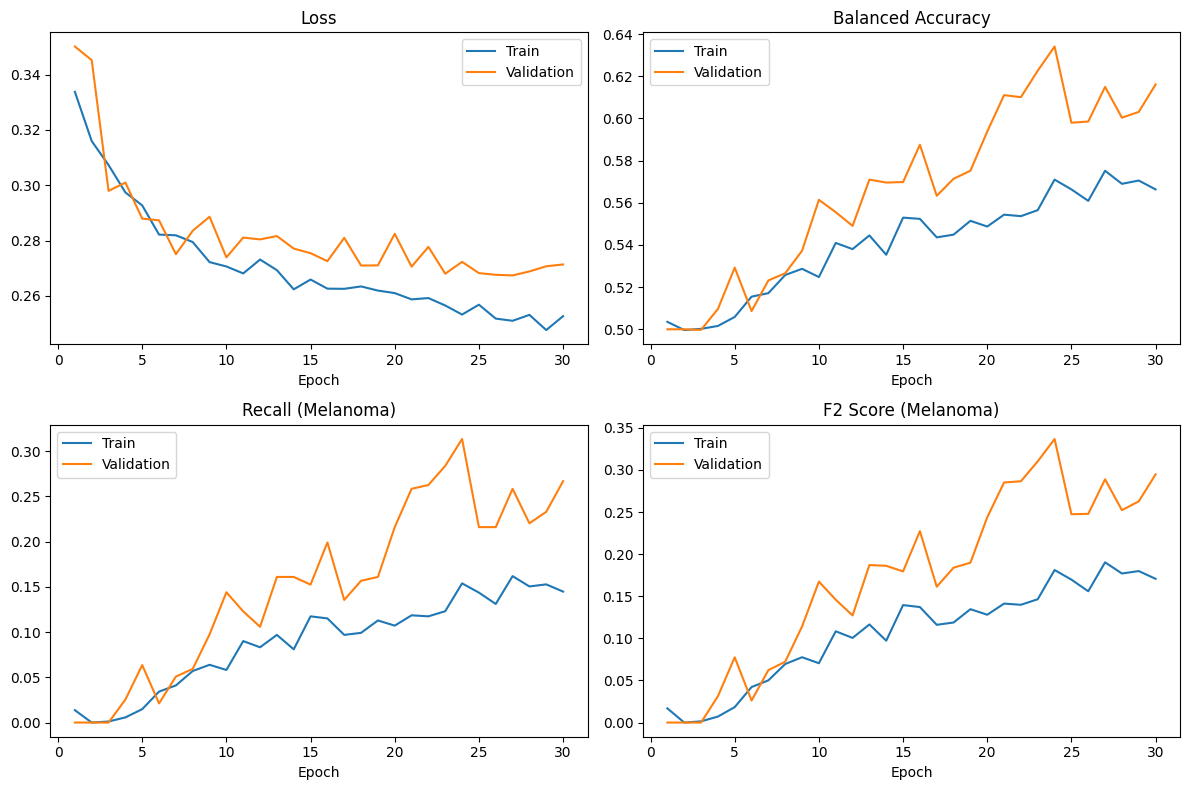

In [7]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [8]:
model.load_state_dict(torch.load(str(ROOT / 'models/densenet121_baseline_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

C:\Users\1008462\AppData\Local\Temp\ipykernel_23780\2815150809.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(ROOT / 'models/densen

Best threshold: 0.13 | Val F2: 0.6029


## Test Set Evaluation

In [9]:
evaluate_model(model, test_loader, device, threshold=best_threshold)

FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "C:\Users\1008462\Desktop\50.021_project_group4\venv\Lib\site-packages\torch\utils\data\_utils\worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\1008462\Desktop\50.021_project_group4\venv\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\1008462\Desktop\50.021_project_group4\venv\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "C:\Users\1008462\Desktop\50.039-Deep-Learning\src\data\dataset.py", line 29, in __getitem__
    raise FileNotFoundError(f"Image not found: {